In [1]:
from processing_answers import *

/Users/alberto/Documents/projects/medLLM/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/alberto/Documents/projects/medLLM/venv/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


MOMENTPipeline(
  (normalizer): RevIN()
  (tokenizer): Patching()
  (patch_embedding): PatchEmbedding(
    (value_embedding): Linear(in_features=8, out_features=1024, bias=False)
    (position_embedding): PositionalEmbedding()
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 1024)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=1024, out_features=1024, bias=False)
              (k): Linear(in_features=1024, out_features=1024, bias=False)
              (v): Linear(in_features=1024, out_features=1024, bias=False)
              (o): Linear(in_features=1024, out_features=1024, bias=False)
              (relative_attention_bias): Embedding(32, 16)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
  

/Users/alberto/Documents/projects/medLLM/venv/lib/python3.11/site-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


In [2]:
total_df = concat_all_results()

In [3]:
total_df

,sequence,complexity,length_type,language,q_length,GPT4_answer,a_length,temperature,real_code,print_code,no_code,explanation,no_sense,exe_out,correct_execution,Levenshtein
0,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",1,0,Mathematica,173,"```mathematica\nTable[2 i, {i, 1, 10}]\n```",41,1.000,0,0,0,0,0,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",True,0
1,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",1,0,Mathematica,174,"```mathematica\nTable[3*n, {n, 1, 10}]\n```",41,1.000,0,0,0,0,0,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",True,0
2,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",1,0,Mathematica,175,"```mathematica\nRange[4, 40, 4]\n```",34,1.000,0,0,0,0,0,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",True,0
3,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",1,0,Mathematica,176,"```mathematica\nTable[5*i, {i, 1, 10}]\n```",41,1.000,0,0,0,0,0,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",True,0
4,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",1,0,Mathematica,176,"```mathematica\nTable[6*i, {i, 1, 10}]\n```",41,1.000,0,0,0,0,0,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,"187, 218, 260, 295, 301, 314, 379, 410, 452, 469",4,0,R,176,"```r\nseq <- c(187, 218, 260, 295, 301, 314, 3...",78,0.001,0,1,0,0,0,"187, 218, 260, 295, 301, 314, 379, 410, 452, 469",True,0
586,"29, 63, 95, 140, 150, 190, 221, 437, 482, 491",4,0,R,173,"```r\nsequence <- c(29, 63, 95, 140, 150, 190,...",85,0.001,0,1,0,0,0,"29, 63, 95, 140, 150, 190, 221, 437, 482, 491",True,0
587,"3, 11, 84, 144, 156, 177, 188, 199, 229, 284",4,0,R,172,"```r\nsequence <- c(3, 11, 84, 144, 156, 177, ...",84,0.001,0,1,0,0,0,", 3, 11, 84, 144, 156, 177, 188, 199, 229, 284",False,2
588,"26, 94, 98, 137, 176, 301, 323, 330, 372, 444",4,0,R,173,"```r\nsequence <- c(26, 94, 98, 137, 176, 301,...",85,0.001,0,1,0,0,0,"26, 94, 98, 137, 176, 301, 323, 330, 372, 444",True,0


In [4]:
# Filter sequences by complexity and temperature
complexity_1_sequences = total_df[(total_df['complexity'] == 1) & (total_df['temperature'] == 1)]['sequence'].tolist()
complexity_2_sequences = total_df[(total_df['complexity'] == 2) & (total_df['temperature'] == 1)]['sequence'].tolist()
complexity_3_sequences = total_df[(total_df['complexity'] == 4) & (total_df['temperature'] == 1)]['sequence'].tolist()

# Print the number of sequences for each complexity
print(f"Number of sequences with complexity 1: {len(complexity_1_sequences)}")
print(f"Number of sequences with complexity 2: {len(complexity_2_sequences)}")
print(f"Number of sequences with complexity 3: {len(complexity_3_sequences)}")





Number of sequences with complexity 1: 210
Number of sequences with complexity 2: 210
Number of sequences with complexity 3: 210


In [5]:
len(complexity_1_sequences), len(complexity_2_sequences), len(complexity_3_sequences)

(210, 210, 210)

In [6]:
# Remove duplicates from complexity_1_sequences
complexity_1_sequences = list(dict.fromkeys(complexity_1_sequences))
complexity_2_sequences = list(dict.fromkeys(complexity_2_sequences))
complexity_3_sequences = list(dict.fromkeys(complexity_3_sequences))

# Print the number of unique sequences
print(f"Number of unique sequences with complexity 1: {len(complexity_1_sequences)}")
print(f"Number of unique sequences with complexity 2: {len(complexity_2_sequences)}")
print(f"Number of unique sequences with complexity 3: {len(complexity_3_sequences)}")


Number of unique sequences with complexity 1: 29
Number of unique sequences with complexity 2: 26
Number of unique sequences with complexity 3: 30


In [7]:
complexity_1_sequences

['2, 4, 6, 8, 10, 12, 14, 16, 18, 20',
 '3, 6, 9, 12, 15, 18, 21, 24, 27, 30',
 '4, 8, 12, 16, 20, 24, 28, 32, 36, 40',
 '5, 10, 15, 20, 25, 30, 35, 40, 45, 50',
 '6, 12, 18, 24, 30, 36, 42, 48, 54, 60',
 '7, 14, 21, 28, 35, 42, 49, 56, 63, 70',
 '8, 16, 24, 32, 40, 48, 56, 64, 72, 80',
 '9, 18, 27, 36, 45, 54, 63, 72, 81, 90',
 '10, 20, 30, 40, 50, 60, 70, 80, 90, 100',
 '1, 3, 5, 7, 9, 11, 13, 15, 17, 19',
 '11, 12, 13, 14, 15, 16, 17, 18, 19, 20',
 '21, 22, 23, 24, 25, 26, 27, 28, 29, 30',
 '31, 32, 33, 34, 35, 36, 37, 38, 39, 40',
 '41, 42, 43, 44, 45, 46, 47, 48, 49, 50',
 '51, 52, 53, 54, 55, 56, 57, 58, 59, 60',
 '61, 62, 63, 64, 65, 66, 67, 68, 69, 70',
 '71, 72, 73, 74, 75, 76, 77, 78, 79, 80',
 '81, 82, 83, 84, 85, 86, 87, 88, 89, 90',
 '91, 92, 93, 94, 95, 96, 97, 98, 99, 100',
 '101, 102, 103, 104, 105, 106, 107, 108, 109, 110',
 '111, 112, 113, 114, 115, 116, 117, 118, 119, 120',
 '121, 122, 123, 124, 125, 126, 127, 128, 129, 130',
 '131, 132, 133, 134, 135, 136, 137, 138,

In [8]:
complexity_2_sequences

['2, 3, 5, 7, 11, 13, 17, 19, 23, 29',
 '1, 1, 2, 3, 5, 8, 13, 21, 34, 55',
 '1, 2, 4, 8, 16, 32, 64, 128, 256, 512',
 '1, 3, 9, 27, 81, 243, 729, 2187, 6561, 19683',
 '1, 4, 9, 16, 25, 36, 49, 64, 81, 100',
 '1, 8, 27, 64, 125, 216, 343, 512, 729, 1000',
 '1, 1, 2, 6, 24, 120, 720, 5040, 40320, 362880',
 '1, 3, 6, 10, 15, 21, 28, 36, 45, 55',
 '2, 1, 3, 4, 7, 11, 18, 29, 47, 76',
 '0, 1, 2, 5, 12, 29, 70, 169, 408, 985',
 '1, 4, 27, 256, 3125, 46656, 823543, 16777216, 387420489, 10000000000',
 '1, 2, 6, 20, 70, 252, 924, 3432, 12870, 48620',
 '4, 6, 9, 10, 14, 15, 21, 22, 25, 26',
 '1, 10, 11, 100, 101, 110, 111, 1000, 1001, 1010',
 '0, 1, 81, 512, 2401, 4913, 5832, 17576, 19683, 234256',
 '1, 2, 145, 40585',
 '2, 5, 12, 20, 29, 39, 50, 62, 75, 89',
 '1, 8, 10, 18, 19, 100, 101, 108, 109, 110',
 '3, 7, 31, 127, 2047, 8191, 131071, 524287, 8388607, 536870911',
 '1, 2, 4, 8, 16, 23, 28, 38, 58, 89',
 '1, 2, 4, 8, 15, 26, 42, 64, 93, 129',
 '1, 5, 12, 22, 35, 51, 70, 92, 117, 145',
 '0, 

In [9]:
complexity_3_sequences

['29, 57, 68, 120, 134, 140, 173, 197, 283, 313',
 '24, 26, 36, 40, 184, 226, 244, 384, 391, 423',
 '90, 203, 212, 235, 270, 324, 342, 352, 371, 417',
 '20, 48, 95, 234, 282, 296, 352, 402, 428, 481',
 '62, 98, 130, 154, 290, 315, 324, 385, 408, 447',
 '2, 42, 66, 102, 153, 195, 201, 252, 306, 396',
 '128, 151, 153, 217, 224, 332, 382, 400, 450, 478',
 '26, 50, 114, 148, 160, 170, 274, 347, 432, 497',
 '48, 94, 176, 177, 219, 276, 282, 283, 459, 488',
 '139, 252, 272, 281, 304, 361, 370, 415, 438, 500',
 '15, 95, 115, 195, 240, 318, 326, 350, 432, 450',
 '134, 224, 293, 378, 379, 395, 434, 451, 482, 496',
 '23, 93, 142, 145, 245, 266, 296, 317, 428, 495',
 '18, 39, 71, 194, 197, 219, 263, 270, 416, 473',
 '9, 84, 144, 170, 325, 393, 401, 405, 435, 497',
 '26, 40, 202, 267, 282, 340, 359, 408, 410, 495',
 '34, 92, 164, 165, 209, 296, 414, 456, 467, 494',
 '16, 119, 121, 123, 135, 139, 285, 311, 409, 412',
 '8, 11, 12, 103, 116, 196, 247, 254, 389, 427',
 '12, 36, 96, 119, 171, 213, 221,

In [10]:
import pandas as pd

In [11]:
formulas_ds = pd.read_csv('formulas_found_by_llm.csv')
# Replace '***' and NaN values with random 30-char alphanumeric strings
import random
import string

def generate_random_string(length=45):
    """Generate a random alphanumeric string of given length"""
    characters = string.ascii_letters + string.digits
    return ''.join(random.choice(characters) for _ in range(length))

# Replace '***' values
formulas_ds = formulas_ds.replace('***', generate_random_string())

# Replace NaN values 
formulas_ds = formulas_ds.fillna(generate_random_string())

formulas_ds

,sequence,complexity,chatgpt-4o,gpt-4o-mini,gemini-1.5-advanced,gemini-thinking,claude-3.5-sonnet,chatgpt-o1,mistral,meta,...,grok_4,opus_4,mistral_large2405,gemini_2.5_pro,claude_sonnet_4,grok-4.1,chatgpt-5.2,claude-4.5,gemini-3-pro,mistral-large-3
0,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",1,2n,2n,2n,"a_n = 2n, for n >= 1",2n,2n,2*n,lambda n: 2n,...,2*n,2*n,2n,2*n,2*n,2*n,2*n,2*n,2*n,2*n
1,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",1,3n,3n,3n,"a_n = 3n, for n >= 1",3n,3n,3*n,lambda n: 3n,...,3*n,3*n,3n,3*n,3*n,3*n,3*n,3*n,3*n,3*n
2,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",1,4n,4n,4n,"a_n = 4n, for n >= 1",4n,4n,4*n,lambda n: 4n,...,4*n,4*n,4n,4*n,4*n,4*n,4*n,4*n,4*n,4*n
3,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",1,5n,5n,5n,"a_n = 5n, for n >= 1",5n,5n,5*n,lambda n: 5n,...,5*n,5*n,5n,5*n,5*n,5*n,5*n,5*n,5*n,5*n
4,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",1,6n,6n,6n,"a_n = 6n, for n >= 1",6n,6n,6*n,lambda n: 6n,...,6*n,6*n,6n,6*n,6*n,6*n,6*n,6*n,6*n,6*n
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,"187, 218, 260, 295, 301, 314, 379, 410, 452, 469",3,"187, 218, 260, 295, 301, 314, 379, 410, 452, 469","187, 218, 260, 295, 301, 314, 379, 410, 452, 469",utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,"187, 218, 260, 295, 301, 314, 379, 410, 452, 469",utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,...,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt
81,"29, 63, 95, 140, 150, 190, 221, 437, 482, 491",3,"29, 63, 95, 140, 150, 190, 221, 437, 482, 491","29, 63, 95, 140, 150, 190, 221, 437, 482, 491",utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,"29, 63, 95, 140, 150, 190, 221, 437, 482, 491",utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,...,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt
82,"3, 11, 84, 144, 156, 177, 188, 199, 229, 284",3,"3, 11, 84, 144, 156, 177, 188, 199, 229, 284","3, 11, 84, 144, 156, 177, 188, 199, 229, 284",utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,"3, 11, 84, 144, 156, 177, 188, 199, 229, 284",utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,...,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt
83,"26, 94, 98, 137, 176, 301, 323, 330, 372, 444",3,"26, 94, 98, 137, 176, 301, 323, 330, 372, 444","26, 94, 98, 137, 176, 301, 323, 330, 372, 444",utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt,"26, 94, 98, 137, 176, 301, 323, 330

In [12]:
print(formulas_ds.columns)
print(len(formulas_ds))

Index(['sequence', 'complexity', 'chatgpt-4o', 'gpt-4o-mini',
       'gemini-1.5-advanced', 'gemini-thinking', 'claude-3.5-sonnet',
       'chatgpt-o1', 'mistral', 'meta', 'o1-mini', 'cursor_small', 'grok',
       'qwen', 'deepseek', 'grok-3', 'chatgpt-4.5', 'claude_3.7',
       'deepseek_r1_0525', 'llama_4_scout', 'qwen3', 'chatgpt_5', 'grok_4',
       'opus_4', 'mistral_large2405', 'gemini_2.5_pro', 'claude_sonnet_4',
       'grok-4.1', 'chatgpt-5.2', 'claude-4.5', 'gemini-3-pro',
       'mistral-large-3'],
      dtype='object')
85


In [13]:
import numpy as np
import zlib
import lzma
import base64

In [14]:
def convert_to_numeric(string_list):
    return list(map(int, string_list.split(',')))

def to_number(list_strings):
    return [list(map(int, num_str.split(','))) for num_str in list_strings]

def to_digit_lists(number_strings):
    def to_binary(num, length=4):
        return [int(b) for b in format(num, f'0{length}b')]

    all_digits_lists = []
    
    for number_string in number_strings:
        number_list = number_string.split(',')
        digit_list = []
        for number in number_list:
            for char in number.strip():
                digit_list.extend(to_binary(int(char)))
        all_digits_lists.append(digit_list)
    
    return all_digits_lists

def normalize_binary_sequences(binary_seq):
    # a) Compute average length
    avg_length = round(np.mean([len(seq) for seq in binary_seq]))
    
    # b) Clean list based on average length
    clean_binary_seq_by_avg = [
        np.array(seq[:avg_length], dtype=int) for seq in binary_seq if len(seq) >= avg_length
    ]
    
    return avg_length, clean_binary_seq_by_avg

from pybdm import BDM
def compute_avg_bdm(norm_bin_sequences_list):
    bdm = BDM(ndim=1)
    
    # Compute BDM for each sequence
    bdm_values = [bdm.bdm(seq) for seq in norm_bin_sequences_list]
    
    # Calculate the average BDM
    avg_bdm = np.mean(bdm_values)
    
    return avg_bdm

def compress_text(text):
    # Apply LZW compression using lzma (LZMA is a variant of LZW)
    lzw_compressed = lzma.compress(text.encode('utf-8'))
    
    # Apply ZIP compression using zlib
    zip_compressed = zlib.compress(text.encode('utf-8'))
    
    # Encode the compressed data to Base64
    lzw_compressed_base64 = base64.b64encode(lzw_compressed).decode('utf-8')
    zip_compressed_base64 = base64.b64encode(zip_compressed).decode('utf-8')
    
    return lzw_compressed_base64, zip_compressed_base64

def decompress_text(lzw_compressed_base64, zip_compressed_base64):
    # Decode the Base64 encoded string
    lzw_compressed = base64.b64decode(lzw_compressed_base64)
    zip_compressed = base64.b64decode(zip_compressed_base64)
    
    # Decompress LZW
    lzw_decompressed = lzma.decompress(lzw_compressed).decode('utf-8')
    
    # Decompress ZIP
    zip_decompressed = zlib.decompress(zip_compressed).decode('utf-8')
    
    return lzw_decompressed, zip_decompressed
    
    
def ascii_to_binary_list(text):
    binary_list = []
    for char in text:
        # Convert each character to its binary representation
        binary_representation = format(ord(char), '08b')
        # Extend the binary_list with the numerical digits of the binary representation
        binary_list.extend([int(bit) for bit in binary_representation])
    return binary_list
    
def list_of_strings_to_binary_lists(strings_list):
    binary_lists = [ascii_to_binary_list(string) for string in strings_list]
    return binary_lists

def list_of_strings_to_compressed(strings_list):
    lzw_compressed_list = []
    zip_compressed_list = []
    
    for string in strings_list:
        lzw_compressed, zip_compressed = compress_text(string)
        lzw_compressed_list.append(lzw_compressed)
        zip_compressed_list.append(zip_compressed)
    
    return lzw_compressed_list, zip_compressed_list


import numpy as np
from pybdm import BDM

def normalize_multiple_binary_sequences(binary_seq_sets):
    # a) Compute average length for each set
    avg_lengths = [round(np.mean([len(seq) for seq in binary_seq])) for binary_seq in binary_seq_sets]
    
    # b) Select the lower calculated average
    min_avg_length = min(avg_lengths)
    
    # c) Modify each sequence in each set to the lower average length
    normalized_sets = [
        [np.array(seq[:min_avg_length], dtype=int) for seq in binary_seq if len(seq) >= min_avg_length]
        for binary_seq in binary_seq_sets
    ]
    
    return min_avg_length, normalized_sets

def compute_avg_bdm(norm_bin_sequences_list):
    bdm = BDM(ndim=1)
    bdm_values = [bdm.bdm(seq) for seq in norm_bin_sequences_list]
    shannon_values = [bdm.ent(seq) for seq in norm_bin_sequences_list]
    return np.mean(bdm_values), np.mean(shannon_values)

def list_of_lists_to_np_arrays(list_of_lists):
    return [np.array(sublist) for sublist in list_of_lists]

def transform_to_np_arrays(list_of_lists_of_lists):
    return [list_of_lists_to_np_arrays(sublist) for sublist in list_of_lists_of_lists]


def process_binary_sequences(binary_seq_sets, normalize=True):
    # Normalize all sets to the minimum average length
    if normalize == False:
        min_avg_length = None
        normalized_bin_sets = transform_to_np_arrays(binary_seq_sets)
    else:
        min_avg_length, normalized_bin_sets = normalize_multiple_binary_sequences(binary_seq_sets)
    
    # d) Calculate avg bdm and avg shannon for each normalized set
    avg_bdm_values, avg_shannon_values = zip(*(compute_avg_bdm(norm_set) for norm_set in normalized_bin_sets))
    
    return min_avg_length, list(avg_bdm_values), list(avg_shannon_values)

In [15]:
# ChatGPT-o1
chatgpt_o1_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['chatgpt-o1'] == formulas_ds['sequence'])]['chatgpt-o1'].tolist()
chatgpt_o1_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['chatgpt-o1'] != formulas_ds['sequence'])]['chatgpt-o1'].tolist()
chatgpt_o1_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['chatgpt-o1'] == formulas_ds['sequence'])]['chatgpt-o1'].tolist()
chatgpt_o1_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['chatgpt-o1'] != formulas_ds['sequence'])]['chatgpt-o1'].tolist()
chatgpt_o1_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['chatgpt-o1'] == formulas_ds['sequence'])]['chatgpt-o1'].tolist()
chatgpt_o1_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['chatgpt-o1'] != formulas_ds['sequence'])]['chatgpt-o1'].tolist()

# Grok
grok_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['grok'] == formulas_ds['sequence'])]['grok'].tolist()
grok_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['grok'] != formulas_ds['sequence'])]['grok'].tolist()
grok_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['grok'] == formulas_ds['sequence'])]['grok'].tolist()
grok_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['grok'] != formulas_ds['sequence'])]['grok'].tolist()
grok_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['grok'] == formulas_ds['sequence'])]['grok'].tolist()
grok_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['grok'] != formulas_ds['sequence'])]['grok'].tolist()

# Gemini 1.5 Advanced
gemini_1_5_advanced_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['gemini-1.5-advanced'] == formulas_ds['sequence'])]['gemini-1.5-advanced'].tolist()
gemini_1_5_advanced_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['gemini-1.5-advanced'] != formulas_ds['sequence'])]['gemini-1.5-advanced'].tolist()
gemini_1_5_advanced_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['gemini-1.5-advanced'] == formulas_ds['sequence'])]['gemini-1.5-advanced'].tolist()
gemini_1_5_advanced_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['gemini-1.5-advanced'] != formulas_ds['sequence'])]['gemini-1.5-advanced'].tolist()
gemini_1_5_advanced_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['gemini-1.5-advanced'] == formulas_ds['sequence'])]['gemini-1.5-advanced'].tolist()
gemini_1_5_advanced_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['gemini-1.5-advanced'] != formulas_ds['sequence'])]['gemini-1.5-advanced'].tolist()

# Claude
claude_3_5_sonnet_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['claude-3.5-sonnet'] == formulas_ds['sequence'])]['claude-3.5-sonnet'].tolist()
claude_3_5_sonnet_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['claude-3.5-sonnet'] != formulas_ds['sequence'])]['claude-3.5-sonnet'].tolist()
claude_3_5_sonnet_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['claude-3.5-sonnet'] == formulas_ds['sequence'])]['claude-3.5-sonnet'].tolist()
claude_3_5_sonnet_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['claude-3.5-sonnet'] != formulas_ds['sequence'])]['claude-3.5-sonnet'].tolist()
claude_3_5_sonnet_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['claude-3.5-sonnet'] == formulas_ds['sequence'])]['claude-3.5-sonnet'].tolist()
claude_3_5_sonnet_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['claude-3.5-sonnet'] != formulas_ds['sequence'])]['claude-3.5-sonnet'].tolist()

# GPT-4o-mini
gpt_4o_mini_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['gpt-4o-mini'] == formulas_ds['sequence'])]['gpt-4o-mini'].tolist()
gpt_4o_mini_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['gpt-4o-mini'] != formulas_ds['sequence'])]['gpt-4o-mini'].tolist()
gpt_4o_mini_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['gpt-4o-mini'] == formulas_ds['sequence'])]['gpt-4o-mini'].tolist()
gpt_4o_mini_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['gpt-4o-mini'] != formulas_ds['sequence'])]['gpt-4o-mini'].tolist()
gpt_4o_mini_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['gpt-4o-mini'] == formulas_ds['sequence'])]['gpt-4o-mini'].tolist()
gpt_4o_mini_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['gpt-4o-mini'] != formulas_ds['sequence'])]['gpt-4o-mini'].tolist()

# o1-mini
o1_mini_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['o1-mini'] == formulas_ds['sequence'])]['o1-mini'].tolist()
o1_mini_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['o1-mini'] != formulas_ds['sequence'])]['o1-mini'].tolist()
o1_mini_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['o1-mini'] == formulas_ds['sequence'])]['o1-mini'].tolist()
o1_mini_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['o1-mini'] != formulas_ds['sequence'])]['o1-mini'].tolist()
o1_mini_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['o1-mini'] == formulas_ds['sequence'])]['o1-mini'].tolist()
o1_mini_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['o1-mini'] != formulas_ds['sequence'])]['o1-mini'].tolist()

# Additional lists divided by model and complexity
chatgpt_o1_1 = formulas_ds[formulas_ds['complexity'] == 1]['chatgpt-o1'].tolist()
chatgpt_o1_2 = formulas_ds[formulas_ds['complexity'] == 2]['chatgpt-o1'].tolist()
chatgpt_o1_3 = formulas_ds[formulas_ds['complexity'] == 3]['chatgpt-o1'].tolist()

grok_1 = formulas_ds[formulas_ds['complexity'] == 1]['grok'].tolist()
grok_2 = formulas_ds[formulas_ds['complexity'] == 2]['grok'].tolist()
grok_3 = formulas_ds[formulas_ds['complexity'] == 3]['grok'].tolist()

gemini_1_5_advanced_1 = formulas_ds[formulas_ds['complexity'] == 1]['gemini-1.5-advanced'].tolist()
gemini_1_5_advanced_2 = formulas_ds[formulas_ds['complexity'] == 2]['gemini-1.5-advanced'].tolist()
gemini_1_5_advanced_3 = formulas_ds[formulas_ds['complexity'] == 3]['gemini-1.5-advanced'].tolist()

claude_3_5_sonnet_1 = formulas_ds[formulas_ds['complexity'] == 1]['claude-3.5-sonnet'].tolist()
claude_3_5_sonnet_2 = formulas_ds[formulas_ds['complexity'] == 2]['claude-3.5-sonnet'].tolist()
claude_3_5_sonnet_3 = formulas_ds[formulas_ds['complexity'] == 3]['claude-3.5-sonnet'].tolist()

gpt_4o_mini_1 = formulas_ds[formulas_ds['complexity'] == 1]['gpt-4o-mini'].tolist()
gpt_4o_mini_2 = formulas_ds[formulas_ds['complexity'] == 2]['gpt-4o-mini'].tolist()
gpt_4o_mini_3 = formulas_ds[formulas_ds['complexity'] == 3]['gpt-4o-mini'].tolist()

o1_mini_1 = formulas_ds[formulas_ds['complexity'] == 1]['o1-mini'].tolist()
o1_mini_2 = formulas_ds[formulas_ds['complexity'] == 2]['o1-mini'].tolist()
o1_mini_3 = formulas_ds[formulas_ds['complexity'] == 3]['o1-mini'].tolist()

# Gemini Thinking
gemini_thinking_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['gemini-thinking'] == formulas_ds['sequence'])]['gemini-thinking'].tolist()
gemini_thinking_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['gemini-thinking'] != formulas_ds['sequence'])]['gemini-thinking'].tolist()
gemini_thinking_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['gemini-thinking'] == formulas_ds['sequence'])]['gemini-thinking'].tolist()
gemini_thinking_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['gemini-thinking'] != formulas_ds['sequence'])]['gemini-thinking'].tolist()
gemini_thinking_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['gemini-thinking'] == formulas_ds['sequence'])]['gemini-thinking'].tolist()
gemini_thinking_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['gemini-thinking'] != formulas_ds['sequence'])]['gemini-thinking'].tolist()

# Additional lists divided by model and complexity
gemini_thinking_1 = formulas_ds[formulas_ds['complexity'] == 1]['gemini-thinking'].tolist()
gemini_thinking_2 = formulas_ds[formulas_ds['complexity'] == 2]['gemini-thinking'].tolist()
gemini_thinking_3 = formulas_ds[formulas_ds['complexity'] == 3]['gemini-thinking'].tolist()

# Mistral
mistral_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['mistral'] == formulas_ds['sequence'])]['mistral'].tolist()
mistral_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['mistral'] != formulas_ds['sequence'])]['mistral'].tolist()
mistral_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['mistral'] == formulas_ds['sequence'])]['mistral'].tolist()
mistral_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['mistral'] != formulas_ds['sequence'])]['mistral'].tolist()
mistral_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['mistral'] == formulas_ds['sequence'])]['mistral'].tolist()
mistral_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['mistral'] != formulas_ds['sequence'])]['mistral'].tolist()

# Additional lists divided by model and complexity
mistral_1 = formulas_ds[formulas_ds['complexity'] == 1]['mistral'].tolist()
mistral_2 = formulas_ds[formulas_ds['complexity'] == 2]['mistral'].tolist()
mistral_3 = formulas_ds[formulas_ds['complexity'] == 3]['mistral'].tolist()

# Meta
meta_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['meta'] == formulas_ds['sequence'])]['meta'].tolist()
meta_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['meta'] != formulas_ds['sequence'])]['meta'].tolist()
meta_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['meta'] == formulas_ds['sequence'])]['meta'].tolist()
meta_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['meta'] != formulas_ds['sequence'])]['meta'].tolist()
meta_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['meta'] == formulas_ds['sequence'])]['meta'].tolist()
meta_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['meta'] != formulas_ds['sequence'])]['meta'].tolist()

# Additional lists divided by model and complexity
meta_1 = formulas_ds[formulas_ds['complexity'] == 1]['meta'].tolist()
meta_2 = formulas_ds[formulas_ds['complexity'] == 2]['meta'].tolist()
meta_3 = formulas_ds[formulas_ds['complexity'] == 3]['meta'].tolist()

# Cursor Small
cursor_small_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['cursor_small'] == formulas_ds['sequence'])]['cursor_small'].tolist()
cursor_small_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['cursor_small'] != formulas_ds['sequence'])]['cursor_small'].tolist()
cursor_small_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['cursor_small'] == formulas_ds['sequence'])]['cursor_small'].tolist()
cursor_small_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['cursor_small'] != formulas_ds['sequence'])]['cursor_small'].tolist()
cursor_small_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['cursor_small'] == formulas_ds['sequence'])]['cursor_small'].tolist()
cursor_small_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['cursor_small'] != formulas_ds['sequence'])]['cursor_small'].tolist()

# Additional lists divided by model and complexity
cursor_small_1 = formulas_ds[formulas_ds['complexity'] == 1]['cursor_small'].tolist()
cursor_small_2 = formulas_ds[formulas_ds['complexity'] == 2]['cursor_small'].tolist()
cursor_small_3 = formulas_ds[formulas_ds['complexity'] == 3]['cursor_small'].tolist()

# Qwen
qwen_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['qwen'] == formulas_ds['sequence'])]['qwen'].tolist()
qwen_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['qwen'] != formulas_ds['sequence'])]['qwen'].tolist()
qwen_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['qwen'] == formulas_ds['sequence'])]['qwen'].tolist()
qwen_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['qwen'] != formulas_ds['sequence'])]['qwen'].tolist()
qwen_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['qwen'] == formulas_ds['sequence'])]['qwen'].tolist()
qwen_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['qwen'] != formulas_ds['sequence'])]['qwen'].tolist()

# Additional lists divided by model and complexity
qwen_1 = formulas_ds[formulas_ds['complexity'] == 1]['qwen'].tolist()
qwen_2 = formulas_ds[formulas_ds['complexity'] == 2]['qwen'].tolist()
qwen_3 = formulas_ds[formulas_ds['complexity'] == 3]['qwen'].tolist()

# Deepseek
deepseek_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['deepseek'] == formulas_ds['sequence'])]['deepseek'].tolist()
deepseek_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['deepseek'] != formulas_ds['sequence'])]['deepseek'].tolist()
deepseek_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['deepseek'] == formulas_ds['sequence'])]['deepseek'].tolist()
deepseek_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['deepseek'] != formulas_ds['sequence'])]['deepseek'].tolist()
deepseek_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['deepseek'] == formulas_ds['sequence'])]['deepseek'].tolist()
deepseek_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['deepseek'] != formulas_ds['sequence'])]['deepseek'].tolist()

# Additional lists divided by model and complexity
deepseek_1 = formulas_ds[formulas_ds['complexity'] == 1]['deepseek'].tolist()
deepseek_2 = formulas_ds[formulas_ds['complexity'] == 2]['deepseek'].tolist()
deepseek_3 = formulas_ds[formulas_ds['complexity'] == 3]['deepseek'].tolist()

# Grok-3
grok_3_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['grok-3'] == formulas_ds['sequence'])]['grok-3'].tolist()
grok_3_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['grok-3'] != formulas_ds['sequence'])]['grok-3'].tolist()
grok_3_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['grok-3'] == formulas_ds['sequence'])]['grok-3'].tolist()
grok_3_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['grok-3'] != formulas_ds['sequence'])]['grok-3'].tolist()
grok_3_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['grok-3'] == formulas_ds['sequence'])]['grok-3'].tolist()
grok_3_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['grok-3'] != formulas_ds['sequence'])]['grok-3'].tolist()

# Additional lists divided by model and complexity
grok_3_1 = formulas_ds[formulas_ds['complexity'] == 1]['grok-3'].tolist()
grok_3_2 = formulas_ds[formulas_ds['complexity'] == 2]['grok-3'].tolist()
grok_3_3 = formulas_ds[formulas_ds['complexity'] == 3]['grok-3'].tolist()

# claude_3.7
claude_3_7_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['claude_3.7'] == formulas_ds['sequence'])]['claude_3.7'].tolist()
claude_3_7_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['claude_3.7'] != formulas_ds['sequence'])]['claude_3.7'].tolist()
claude_3_7_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['claude_3.7'] == formulas_ds['sequence'])]['claude_3.7'].tolist()
claude_3_7_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['claude_3.7'] != formulas_ds['sequence'])]['claude_3.7'].tolist()
claude_3_7_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['claude_3.7'] == formulas_ds['sequence'])]['claude_3.7'].tolist()
claude_3_7_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['claude_3.7'] != formulas_ds['sequence'])]['claude_3.7'].tolist()

# Additional lists divided by model and complexity
claude_3_7_1 = formulas_ds[formulas_ds['complexity'] == 1]['claude_3.7'].tolist()
claude_3_7_2 = formulas_ds[formulas_ds['complexity'] == 2]['claude_3.7'].tolist()
claude_3_7_3 = formulas_ds[formulas_ds['complexity'] == 3]['claude_3.7'].tolist()

# deepseek_r1_0525
deepseek_r1_0525_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['deepseek_r1_0525'] == formulas_ds['sequence'])]['deepseek_r1_0525'].tolist()
deepseek_r1_0525_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['deepseek_r1_0525'] != formulas_ds['sequence'])]['deepseek_r1_0525'].tolist()
deepseek_r1_0525_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['deepseek_r1_0525'] == formulas_ds['sequence'])]['deepseek_r1_0525'].tolist()
deepseek_r1_0525_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['deepseek_r1_0525'] != formulas_ds['sequence'])]['deepseek_r1_0525'].tolist()
deepseek_r1_0525_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['deepseek_r1_0525'] == formulas_ds['sequence'])]['deepseek_r1_0525'].tolist()
deepseek_r1_0525_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['deepseek_r1_0525'] != formulas_ds['sequence'])]['deepseek_r1_0525'].tolist()

# Additional lists divided by model and complexity
deepseek_r1_0525_1 = formulas_ds[formulas_ds['complexity'] == 1]['deepseek_r1_0525'].tolist()
deepseek_r1_0525_2 = formulas_ds[formulas_ds['complexity'] == 2]['deepseek_r1_0525'].tolist()
deepseek_r1_0525_3 = formulas_ds[formulas_ds['complexity'] == 3]['deepseek_r1_0525'].tolist()

# llama_4_scout
llama_4_scout_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['llama_4_scout'] == formulas_ds['sequence'])]['llama_4_scout'].tolist()
llama_4_scout_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['llama_4_scout'] != formulas_ds['sequence'])]['llama_4_scout'].tolist()
llama_4_scout_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['llama_4_scout'] == formulas_ds['sequence'])]['llama_4_scout'].tolist()
llama_4_scout_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['llama_4_scout'] != formulas_ds['sequence'])]['llama_4_scout'].tolist()
llama_4_scout_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['llama_4_scout'] == formulas_ds['sequence'])]['llama_4_scout'].tolist()
llama_4_scout_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['llama_4_scout'] != formulas_ds['sequence'])]['llama_4_scout'].tolist()

# Additional lists divided by model and complexity
llama_4_scout_1 = formulas_ds[formulas_ds['complexity'] == 1]['llama_4_scout'].tolist()
llama_4_scout_2 = formulas_ds[formulas_ds['complexity'] == 2]['llama_4_scout'].tolist()
llama_4_scout_3 = formulas_ds[formulas_ds['complexity'] == 3]['llama_4_scout'].tolist()

# qwen3
qwen3_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['qwen3'] == formulas_ds['sequence'])]['qwen3'].tolist()
qwen3_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['qwen3'] != formulas_ds['sequence'])]['qwen3'].tolist()
qwen3_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['qwen3'] == formulas_ds['sequence'])]['qwen3'].tolist()
qwen3_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['qwen3'] != formulas_ds['sequence'])]['qwen3'].tolist()
qwen3_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['qwen3'] == formulas_ds['sequence'])]['qwen3'].tolist()
qwen3_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['qwen3'] != formulas_ds['sequence'])]['qwen3'].tolist()

# Additional lists divided by model and complexity
qwen3_1 = formulas_ds[formulas_ds['complexity'] == 1]['qwen3'].tolist()
qwen3_2 = formulas_ds[formulas_ds['complexity'] == 2]['qwen3'].tolist()
qwen3_3 = formulas_ds[formulas_ds['complexity'] == 3]['qwen3'].tolist()

# chatgpt_5
chatgpt_5_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['chatgpt_5'] == formulas_ds['sequence'])]['chatgpt_5'].tolist()
chatgpt_5_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['chatgpt_5'] != formulas_ds['sequence'])]['chatgpt_5'].tolist()
chatgpt_5_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['chatgpt_5'] == formulas_ds['sequence'])]['chatgpt_5'].tolist()
chatgpt_5_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['chatgpt_5'] != formulas_ds['sequence'])]['chatgpt_5'].tolist()
chatgpt_5_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['chatgpt_5'] == formulas_ds['sequence'])]['chatgpt_5'].tolist()
chatgpt_5_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['chatgpt_5'] != formulas_ds['sequence'])]['chatgpt_5'].tolist()

# Additional lists divided by model and complexity
chatgpt_5_1 = formulas_ds[formulas_ds['complexity'] == 1]['chatgpt_5'].tolist()
chatgpt_5_2 = formulas_ds[formulas_ds['complexity'] == 2]['chatgpt_5'].tolist()
chatgpt_5_3 = formulas_ds[formulas_ds['complexity'] == 3]['chatgpt_5'].tolist()

# grok_4
grok_4_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['grok_4'] == formulas_ds['sequence'])]['grok_4'].tolist()
grok_4_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['grok_4'] != formulas_ds['sequence'])]['grok_4'].tolist()
grok_4_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['grok_4'] == formulas_ds['sequence'])]['grok_4'].tolist()
grok_4_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['grok_4'] != formulas_ds['sequence'])]['grok_4'].tolist()
grok_4_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['grok_4'] == formulas_ds['sequence'])]['grok_4'].tolist()
grok_4_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['grok_4'] != formulas_ds['sequence'])]['grok_4'].tolist()

# Additional lists divided by model and complexity
grok_4_1 = formulas_ds[formulas_ds['complexity'] == 1]['grok_4'].tolist()
grok_4_2 = formulas_ds[formulas_ds['complexity'] == 2]['grok_4'].tolist()
grok_4_3 = formulas_ds[formulas_ds['complexity'] == 3]['grok_4'].tolist()

# opus_4
opus_4_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['opus_4'] == formulas_ds['sequence'])]['opus_4'].tolist()
opus_4_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['opus_4'] != formulas_ds['sequence'])]['opus_4'].tolist()
opus_4_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['opus_4'] == formulas_ds['sequence'])]['opus_4'].tolist()
opus_4_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['opus_4'] != formulas_ds['sequence'])]['opus_4'].tolist()
opus_4_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['opus_4'] == formulas_ds['sequence'])]['opus_4'].tolist()
opus_4_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['opus_4'] != formulas_ds['sequence'])]['opus_4'].tolist()

# Additional lists divided by model and complexity
opus_4_1 = formulas_ds[formulas_ds['complexity'] == 1]['opus_4'].tolist()
opus_4_2 = formulas_ds[formulas_ds['complexity'] == 2]['opus_4'].tolist()
opus_4_3 = formulas_ds[formulas_ds['complexity'] == 3]['opus_4'].tolist()

# mistral_large2505
mistral_large2405_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['mistral_large2405'] == formulas_ds['sequence'])]['mistral_large2405'].tolist()
mistral_large2405_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['mistral_large2405'] != formulas_ds['sequence'])]['mistral_large2405'].tolist()
mistral_large2405_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['mistral_large2405'] == formulas_ds['sequence'])]['mistral_large2405'].tolist()
mistral_large2405_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['mistral_large2405'] != formulas_ds['sequence'])]['mistral_large2405'].tolist()
mistral_large2405_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['mistral_large2405'] == formulas_ds['sequence'])]['mistral_large2405'].tolist()
mistral_large2405_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['mistral_large2405'] != formulas_ds['sequence'])]['mistral_large2405'].tolist()

# Additional lists divided by model and complexity
mistral_large2405_1 = formulas_ds[formulas_ds['complexity'] == 1]['mistral_large2405'].tolist()
mistral_large2405_2 = formulas_ds[formulas_ds['complexity'] == 2]['mistral_large2405'].tolist()
mistral_large2405_3 = formulas_ds[formulas_ds['complexity'] == 3]['mistral_large2405'].tolist()

# gemini_2.5_pro
gemini_2_5_pro_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['gemini_2.5_pro'] == formulas_ds['sequence'])]['gemini_2.5_pro'].tolist()
gemini_2_5_pro_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['gemini_2.5_pro'] != formulas_ds['sequence'])]['gemini_2.5_pro'].tolist()
gemini_2_5_pro_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['gemini_2.5_pro'] == formulas_ds['sequence'])]['gemini_2.5_pro'].tolist()
gemini_2_5_pro_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['gemini_2.5_pro'] != formulas_ds['sequence'])]['gemini_2.5_pro'].tolist()
gemini_2_5_pro_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['gemini_2.5_pro'] == formulas_ds['sequence'])]['gemini_2.5_pro'].tolist()
gemini_2_5_pro_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['gemini_2.5_pro'] != formulas_ds['sequence'])]['gemini_2.5_pro'].tolist()

# Additional lists divided by model and complexity
gemini_2_5_pro_1 = formulas_ds[formulas_ds['complexity'] == 1]['gemini_2.5_pro'].tolist()
gemini_2_5_pro_2 = formulas_ds[formulas_ds['complexity'] == 2]['gemini_2.5_pro'].tolist()
gemini_2_5_pro_3 = formulas_ds[formulas_ds['complexity'] == 3]['gemini_2.5_pro'].tolist()

# claude_sonnet_4
claude_sonnet_4_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['claude_sonnet_4'] == formulas_ds['sequence'])]['claude_sonnet_4'].tolist()
claude_sonnet_4_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['claude_sonnet_4'] != formulas_ds['sequence'])]['claude_sonnet_4'].tolist()
claude_sonnet_4_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['claude_sonnet_4'] == formulas_ds['sequence'])]['claude_sonnet_4'].tolist()
claude_sonnet_4_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['claude_sonnet_4'] != formulas_ds['sequence'])]['claude_sonnet_4'].tolist()
claude_sonnet_4_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['claude_sonnet_4'] == formulas_ds['sequence'])]['claude_sonnet_4'].tolist()
claude_sonnet_4_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['claude_sonnet_4'] != formulas_ds['sequence'])]['claude_sonnet_4'].tolist()

# Additional lists divided by model and complexity
claude_sonnet_4_1 = formulas_ds[formulas_ds['complexity'] == 1]['claude_sonnet_4'].tolist()
claude_sonnet_4_2 = formulas_ds[formulas_ds['complexity'] == 2]['claude_sonnet_4'].tolist()
claude_sonnet_4_3 = formulas_ds[formulas_ds['complexity'] == 3]['claude_sonnet_4'].tolist()

# chatgpt-4.5
chatgpt_4_5_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['chatgpt-4.5'] == formulas_ds['sequence'])]['chatgpt-4.5'].tolist()
chatgpt_4_5_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['chatgpt-4.5'] != formulas_ds['sequence'])]['chatgpt-4.5'].tolist()
chatgpt_4_5_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['chatgpt-4.5'] == formulas_ds['sequence'])]['chatgpt-4.5'].tolist()
chatgpt_4_5_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['chatgpt-4.5'] != formulas_ds['sequence'])]['chatgpt-4.5'].tolist()
chatgpt_4_5_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['chatgpt-4.5'] == formulas_ds['sequence'])]['chatgpt-4.5'].tolist()
chatgpt_4_5_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['chatgpt-4.5'] != formulas_ds['sequence'])]['chatgpt-4.5'].tolist()

# Additional lists divided by model and complexity
chatgpt_4_5_1 = formulas_ds[formulas_ds['complexity'] == 1]['chatgpt-4.5'].tolist()
chatgpt_4_5_2 = formulas_ds[formulas_ds['complexity'] == 2]['chatgpt-4.5'].tolist()
chatgpt_4_5_3 = formulas_ds[formulas_ds['complexity'] == 3]['chatgpt-4.5'].tolist()

# chatgpt_4o
chatgpt_4o_uncompressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['chatgpt-4o'] == formulas_ds['sequence'])]['chatgpt-4o'].tolist()
chatgpt_4o_compressed_1 = formulas_ds[(formulas_ds['complexity'] == 1) & (formulas_ds['chatgpt-4o'] != formulas_ds['sequence'])]['chatgpt-4o'].tolist()
chatgpt_4o_uncompressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['chatgpt-4o'] == formulas_ds['sequence'])]['chatgpt-4o'].tolist()
chatgpt_4o_compressed_2 = formulas_ds[(formulas_ds['complexity'] == 2) & (formulas_ds['chatgpt-4o'] != formulas_ds['sequence'])]['chatgpt-4o'].tolist()
chatgpt_4o_uncompressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['chatgpt-4o'] == formulas_ds['sequence'])]['chatgpt-4o'].tolist()
chatgpt_4o_compressed_3 = formulas_ds[(formulas_ds['complexity'] == 3) & (formulas_ds['chatgpt-4o'] != formulas_ds['sequence'])]['chatgpt-4o'].tolist()

# Additional lists divided by model and complexity
chatgpt_4o_1 = formulas_ds[formulas_ds['complexity'] == 1]['chatgpt-4o'].tolist()
chatgpt_4o_2 = formulas_ds[formulas_ds['complexity'] == 2]['chatgpt-4o'].tolist()
chatgpt_4o_3 = formulas_ds[formulas_ds['complexity'] == 3]['chatgpt-4o'].tolist()





In [16]:
print('complexity 1')
print(chatgpt_4o_1)
print('complexity 2')
print(gemini_thinking_2)
print('complexity 3')
print(gemini_thinking_3)

# gpt_4o_uncompressed_1, gpt_4o_compressed_1, gpt_4o_uncompressed_2, gpt_4o_compressed_2, gpt_4o_uncompressed_3, gpt_4o_compressed_3, claude_uncompressed_1, claude_compressed_1, claude_uncompressed_2, claude_compressed_2, claude_uncompressed_3, claude_compressed_3, gpt_4o_mini_uncompressed_1, gpt_4o_mini_compressed_1, gpt_4o_mini_uncompressed_2, gpt_4o_mini_compressed_2, gpt_4o_mini_uncompressed_3, gpt_4o_mini_compressed_3, o1_mini_uncompressed_1, o1_mini_compressed_1, o1_mini_uncompressed_2, o1_mini_compressed_2, o1_mini_uncompressed_3, o1_mini_compressed_3




complexity 1
['2n', '3n', '4n', '5n', '6n', '7n', '8n', '9n', '10n', '2n-1', 'n+10', 'n+20', 'n+30', 'n+40', 'n+50', 'n+60', 'n+70', 'n+80', 'n+90', 'n+100', 'n+110', 'n+120', 'n+130', 'n+140', 'n+150', 'n+160', 'n+170', 'n+180', 'n+190']
complexity 2
['a_n = n + 190, for n >= 1', 'a_n is the n-th prime number, for n >= 1', 'a_n = F_n, where F_n is the n-th Fibonacci number, with F_1 = 1, F_2 = 1', 'a_n = 2^(n-1), for n >= 1', 'a_n = 3^(n-1), for n >= 1', 'a_n = n^2, for n >= 1', 'a_n = n^3, for n >= 1', 'a_n = n!, for n >= 1', 'a_n = n(n+1)/2, for n >= 1', 'a_1 = 2, a_2 = 1, a_n = a_{n-1} + a_{n-2} for n > 2', 'a_1 = 0, a_2 = 1, a_n = 2*a_{n-1} + a_{n-2} for n > 2', 'a_n = n^n, for n >= 1', 'a_n = C(2n, n) / (n+1), where C is the binomial coefficient', 'a_n is the n-th prime number, for n >= 1', 'utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt', 'Representation of n in binary', 'a_n = n^(n+2), for n >= 0', 'utDlj7UkztCpi6je8kJYKLxll05R0RQ5nfu9O8B2BIaBt', 'a_1 = 2, a_n = a_{n-1} + n + 1'

In [17]:
bin_ascii = list_of_strings_to_binary_lists(chatgpt_4o_1)
print(bin_ascii)

[[0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0], [0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0], [0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0], [0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0], [0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0], [0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0], [0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0], [0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0], [0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0], [0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1], [0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0], [0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0], [0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0], [0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0], [0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0

In [18]:
lzw_compressed, zip_compressed = list_of_strings_to_compressed(chatgpt_4o_1)
print(lzw_compressed)
print(zip_compressed)


['/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQABMm4AAADySeJ4tyl6bAABGgLcLqV+H7bzfQEAAAAABFla', '/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQABM24AAAD/uDIkJVCTOAABGgLcLqV+H7bzfQEAAAAABFla', '/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQABNG4AAABZcQ4d8ZPVBAABGgLcLqV+H7bzfQEAAAAABFla', '/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQABNW4AAABUgN5BY+o8UAABGgLcLqV+H7bzfQEAAAAABFla', '/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQABNm4AAABDk6+k1WAHrQABGgLcLqV+H7bzfQEAAAAABFla', '/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQABN24AAABOYn/4Rxnu+QABGgLcLqV+H7bzfQEAAAAABFla', '/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQABOG4AAAAPANbWfeeK1QABGgLcLqV+H7bzfQEAAAAABFla', '/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQABOW4AAAAC8QaK755jgQABGgLcLqV+H7bzfQEAAAAABFla', '/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQACMTBuAACpe3sHoVmDvwABGwMLL7kQH7bzfQEAAAAABFla', '/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQADMm4tMQA7eQ70OnVhSgABHARvLJzBH7bzfQEAAAAABFla', '/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQADbisxMACN+GM3V9IazAABHARvLJzBH7bzfQEAAAAABFla', '/Td6WFoAAATm1rRGAgAhARYAAAB0L+WjAQADbisyMACa6xLS4VghMQABHARvLJzBH7bzfQEAAA

In [19]:
# testing normalization
set_test = [bin_ascii]
min_avg, normalized_sets = normalize_binary_sequences(set_test[0])
print(min_avg)
print(normalized_sets)




30
[array([0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0]), array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0]), array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0]), array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0]), array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0]), array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0]), array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0]), array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 0]), array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0]), array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,

In [20]:
bdm_test = compute_avg_bdm(normalized_sets)
print(bdm_test)


(np.float64(65.02588143413999), np.float64(1.0))


In [21]:
set_test_II = [normalized_sets[0][0], []]
print(set_test_II)

[np.int64(0), []]


In [22]:
def average_length_of_strings(strings_list):
    total_length = sum(len(s) for s in strings_list)
    return total_length / len(strings_list) if strings_list else 0

# Function to process sequences for a single model and complexity
def process_model_complexity(sequences, model, complexity):
    bin_sequences = list_of_strings_to_binary_lists(sequences)
    
    # Process sequences
    min_length, avg_bdm, avg_shannon = process_binary_sequences([bin_sequences], normalize=False)
    
    # Process with list_of_strings_to_compressed
    lzw_compressed, zip_compressed = list_of_strings_to_compressed(sequences)
    
    # Convert LZW and ZIP results to binary
    bin_lzw = list_of_strings_to_binary_lists(lzw_compressed)
    bin_zip = list_of_strings_to_binary_lists(zip_compressed)
    
    # Process LZW and ZIP binary sequences
    _, avg_bdm_lzw, avg_shannon_lzw = process_binary_sequences([bin_lzw], normalize=False)
    _, avg_bdm_zip, avg_shannon_zip = process_binary_sequences([bin_zip], normalize=False)
    
    # Calculate average lengths
    avg_lzw = average_length_of_strings(lzw_compressed)
    avg_zip = average_length_of_strings(zip_compressed)
       
    return {
        'min_length': min_length,
        'avg_bdm': avg_bdm,
        'avg_shannon': avg_shannon,
        'avg_lzw': avg_lzw,
        'avg_zip': avg_zip,
        'avg_bdm_lzw': avg_bdm_lzw,
        'avg_shannon_lzw': avg_shannon_lzw,
        'avg_bdm_zip': avg_bdm_zip,
        'avg_shannon_zip': avg_shannon_zip
    }

# Dictionary to store results
results = {
    'chatgpt_4o': {},
    'gpt_4o_mini': {},
    'gemini_1_5_advanced': {},
    'gemini_thinking': {},
    'claude_3_5_sonnet': {},
    'chatgpt_o1': {},
    'mistral': {},
    'meta': {},
    'o1_mini': {},
    'cursor_small': {},
    'grok': {},
    'qwen': {},
    'deepseek': {},
    'grok_3': {},
    'chatgpt_4_5': {},
    'claude_3_7': {},
    'deepseek_r1_0525': {},
    'llama_4_scout': {},
    'qwen3': {},
    'chatgpt_5': {},
    'grok_4': {},
    'opus_4': {},
    'mistral_large2405': {},
    'gemini_2_5_pro': {},
    'claude_sonnet_4': {},
}

# Process all models
models = ['chatgpt_4o', 'gpt_4o_mini',
       'gemini_1_5_advanced', 'gemini_thinking', 'claude_3_5_sonnet',
       'chatgpt_o1', 'mistral', 'meta', 'o1_mini', 'cursor_small', 'grok',
       'qwen', 'deepseek', 'grok_3', 'chatgpt_4_5', 'claude_3_7',
       'deepseek_r1_0525', 'llama_4_scout', 'qwen3', 'chatgpt_5', 'grok_4',
       'opus_4', 'mistral_large2405', 'gemini_2_5_pro', 'claude_sonnet_4']


for model in models:
    print('processing model:', model)
    for complexity in [1, 2, 3]:
        print(f'{model}_{complexity}')
        sequences = eval(f'{model}_{complexity}')
        results[model][complexity] = process_model_complexity(sequences, model, complexity)

import json
print("Results dictionary created for plotting:")
print(json.dumps(results, indent=4))

processing model: chatgpt_4o
chatgpt_4o_1
chatgpt_4o_2
chatgpt_4o_3
processing model: gpt_4o_mini
gpt_4o_mini_1
gpt_4o_mini_2
gpt_4o_mini_3
processing model: gemini_1_5_advanced
gemini_1_5_advanced_1
gemini_1_5_advanced_2
gemini_1_5_advanced_3
processing model: gemini_thinking
gemini_thinking_1
gemini_thinking_2
gemini_thinking_3
processing model: claude_3_5_sonnet
claude_3_5_sonnet_1
claude_3_5_sonnet_2
claude_3_5_sonnet_3
processing model: chatgpt_o1
chatgpt_o1_1
chatgpt_o1_2
chatgpt_o1_3
processing model: mistral
mistral_1
mistral_2
mistral_3
processing model: meta
meta_1
meta_2
meta_3
processing model: o1_mini
o1_mini_1
o1_mini_2
o1_mini_3
processing model: cursor_small
cursor_small_1
cursor_small_2
cursor_small_3
processing model: grok
grok_1
grok_2
grok_3
processing model: qwen
qwen_1
qwen_2
qwen_3
processing model: deepseek
deepseek_1
deepseek_2
deepseek_3
processing model: grok_3
grok_3_1
grok_3_2
grok_3_3
processing model: chatgpt_4_5
chatgpt_4_5_1
chatgpt_4_5_2
chatgpt_4_5_3


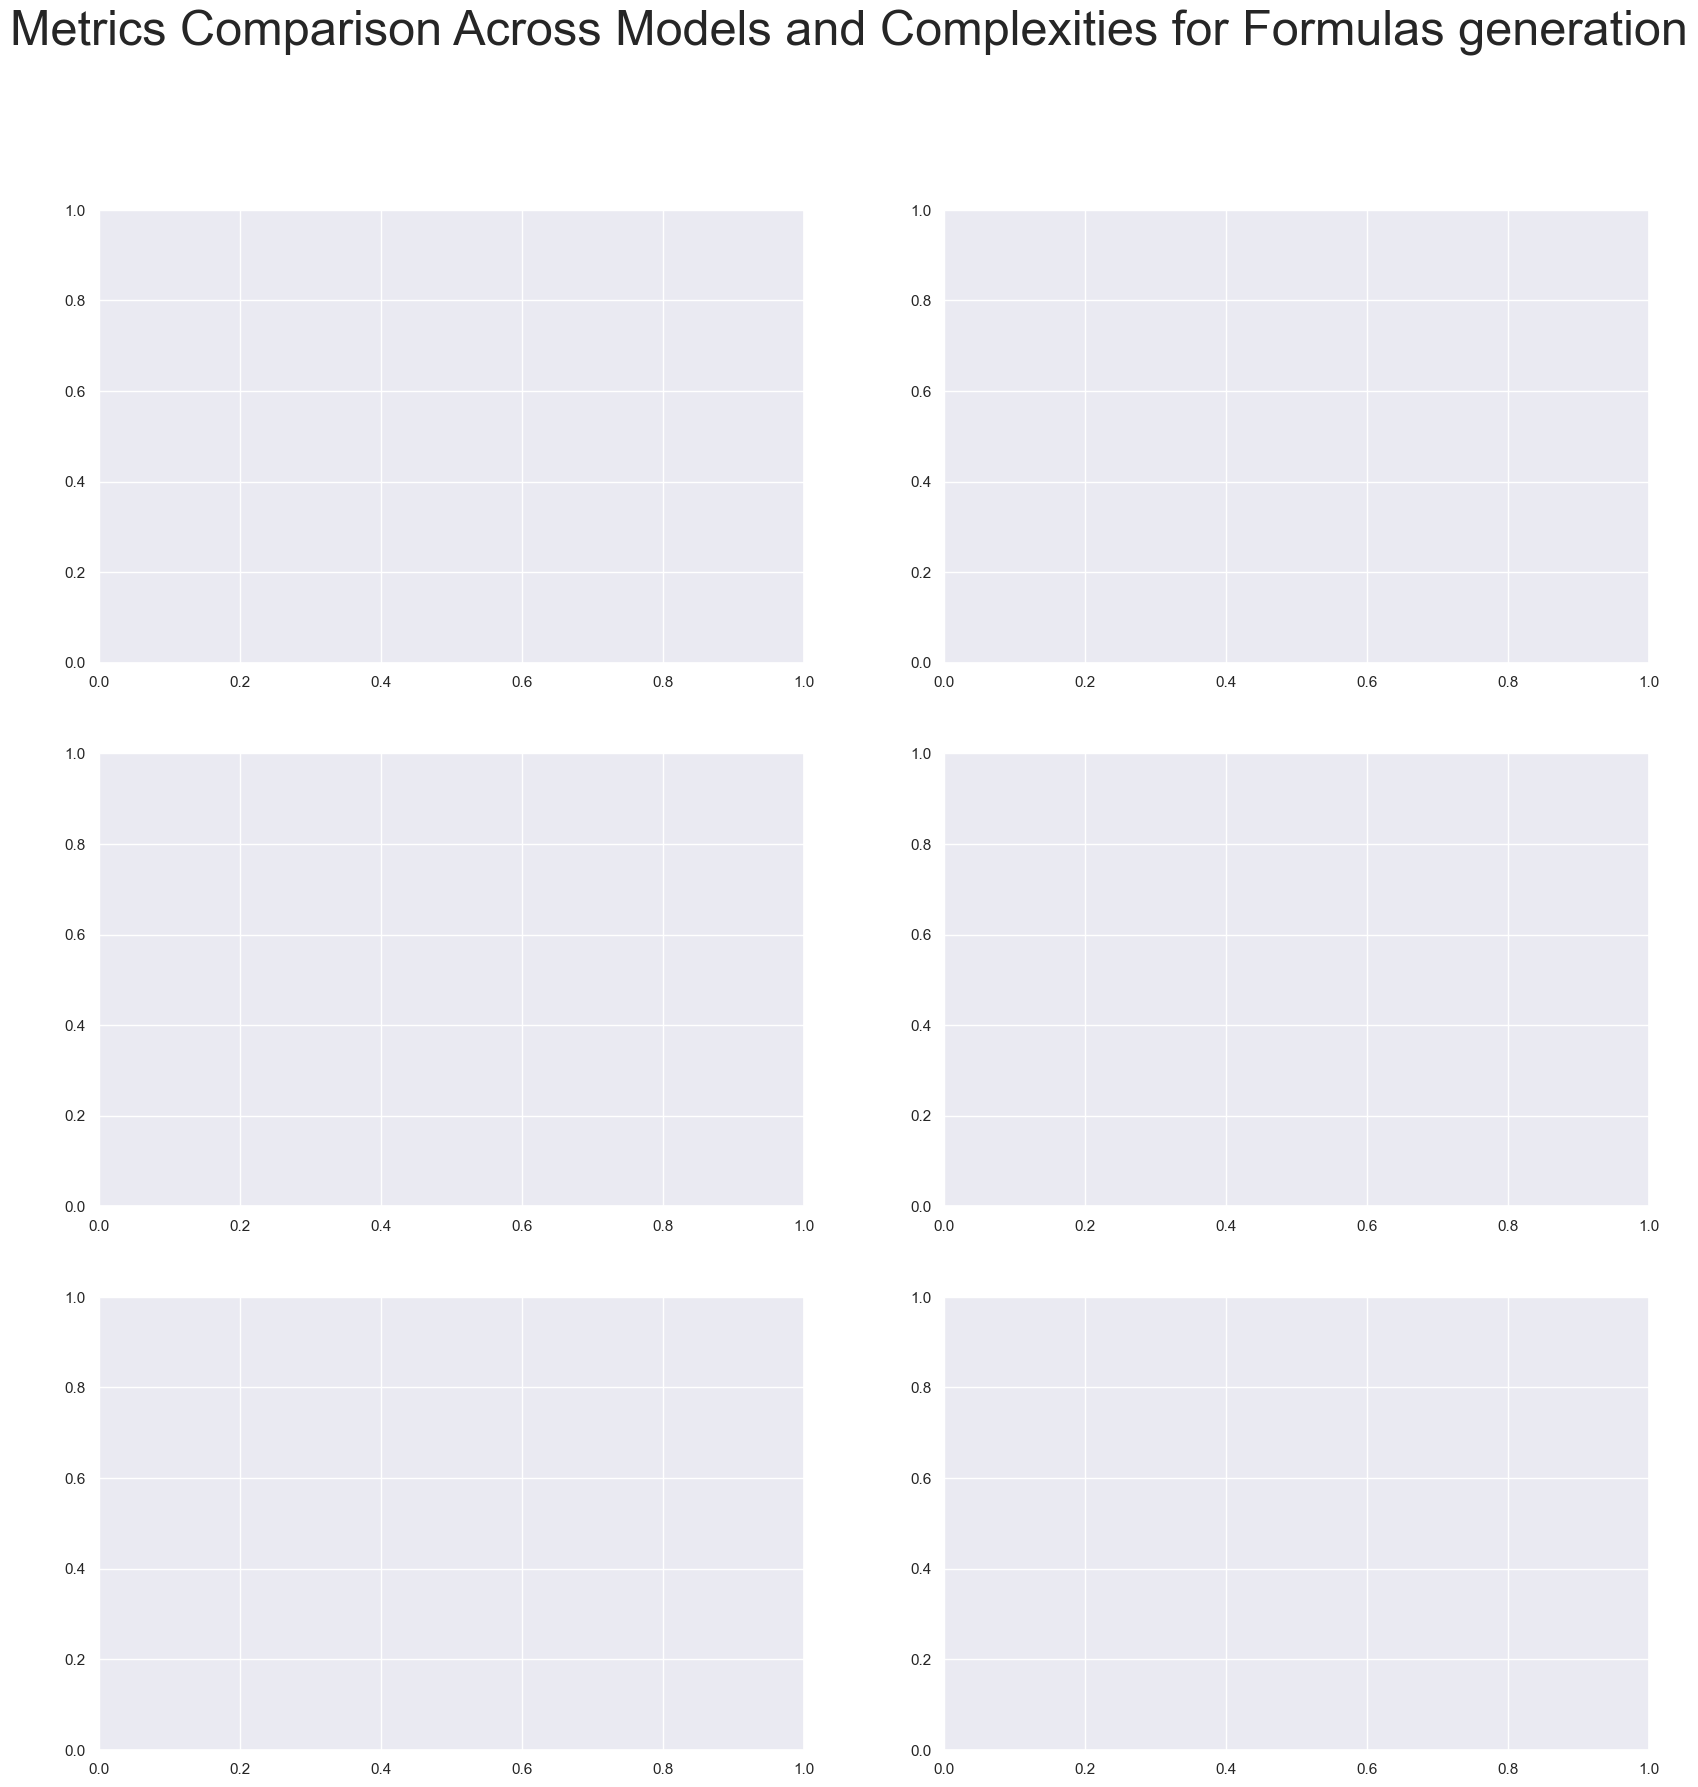

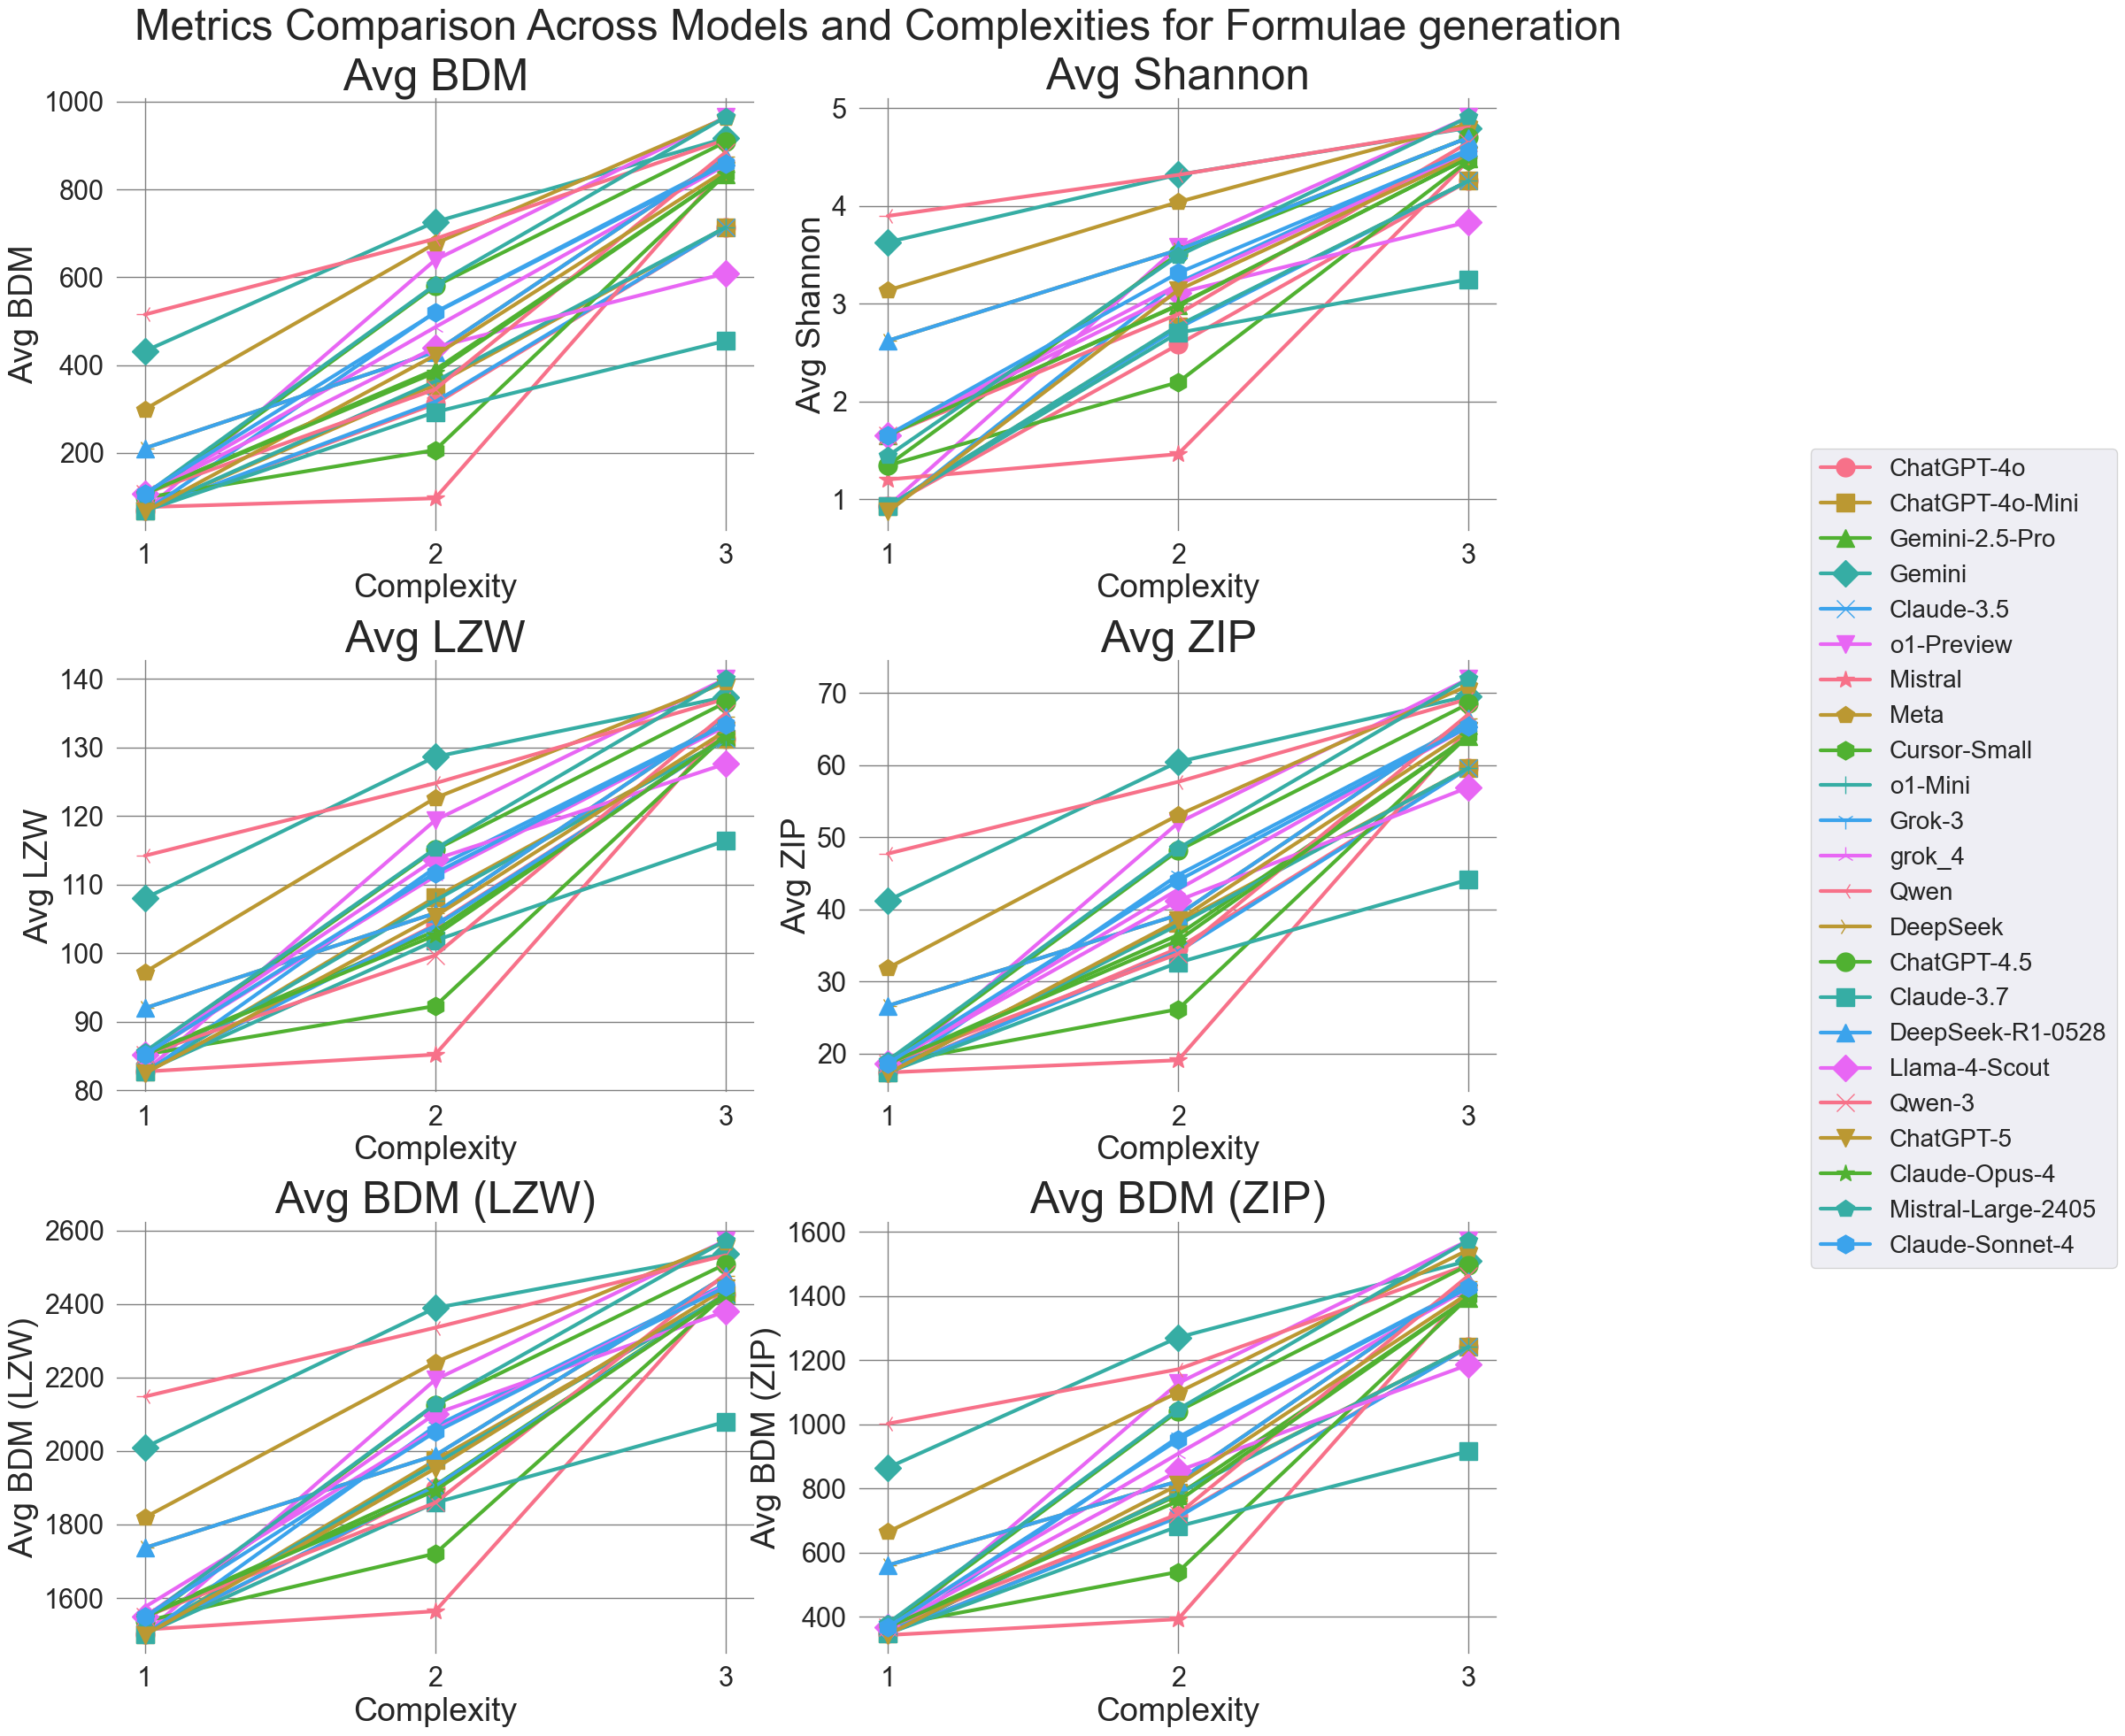

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to replace 'NaN' strings with zeros in the results dictionary
def replace_nan_strings_with_zero(d):
    if isinstance(d, dict):
        return {k: replace_nan_strings_with_zero(v) for k, v in d.items()}
    elif isinstance(d, list):
        return [replace_nan_strings_with_zero(v) for v in d]
    elif isinstance(d, str) and d == 'NaN':
        return 0
    else:
        return d

# Replace 'NaN' strings with zeros
results = replace_nan_strings_with_zero(results)

# Set up the plot style
sns.set_theme(style="darkgrid") 
sns.set_palette("husl")

# Create a single figure with subplots
fig, axs = plt.subplots(3, 2, figsize=(20, 20))

fig.suptitle('Metrics Comparison Across Models and Complexities for Formulas generation', fontsize=35)

# List of metrics to plot (removed 'avg_shannon_lzw' and 'avg_shannon_zip')
metrics = ['avg_bdm', 'avg_shannon', 'avg_lzw', 'avg_zip', 'avg_bdm_lzw', 'avg_bdm_zip']
metric_names = ['Avg BDM', 'Avg Shannon', 'Avg LZW', 'Avg ZIP', 'Avg BDM (LZW)', 'Avg BDM (ZIP)']

# List of models
models = [
        'chatgpt_4o', 
        'gpt_4o_mini',
        'gemini_2_5_pro',
        'gemini_thinking', 
        'claude_3_5_sonnet',
        'chatgpt_o1',
        'mistral', 
        'meta', 
        'cursor_small',
        'o1_mini',
        'grok_3', 
        'grok_4',
        'qwen', 
        'deepseek',
        'chatgpt_4_5', 
        'claude_3_7',
        'deepseek_r1_0525',
        'llama_4_scout', 
        'qwen3',
        'chatgpt_5',
        'opus_4', 
        'mistral_large2405', 
        'claude_sonnet_4',
        
        # 'grok',
        # 'gemini_1_5_advanced', 
        ]

def get_model_display_name(model_key):
    """Map internal model key to display name using the predefined mapping."""
    model_name_mapping = {
        'chatgpt_4o': 'ChatGPT-4o',
        'gpt_4o_mini': 'ChatGPT-4o-Mini',
        'gemini_2_5_pro': 'Gemini-2.5-Pro',
        'gemini_thinking': 'Gemini',
        'claude_3_5_sonnet': 'Claude-3.5',
        'chatgpt_o1': 'o1-Preview',
        'mistral': 'Mistral',
        'meta': 'Meta',
        'cursor_small': 'Cursor-Small',
        'o1_mini': 'o1-Mini',
        'grok_3': 'Grok-3',
        'grok4': 'Grok-4',
        'qwen': 'Qwen',
        'deepseek': 'DeepSeek',
        'chatgpt_4_5': 'ChatGPT-4.5',
        'claude_3_7': 'Claude-3.7',
        'deepseek_r1_0525': 'DeepSeek-R1-0528',
        'llama_4_scout': 'Llama-4-Scout',
        'qwen3': 'Qwen-3',
        'chatgpt_5': 'ChatGPT-5',
        'opus_4': 'Claude-Opus-4',
        'mistral_large2405': 'Mistral-Large-2405',
        'claude_sonnet_4': 'Claude-Sonnet-4',
    }
    return model_name_mapping.get(model_key, model_key)

# def get_model_display_name(model_key):
#     """Map internal model key to display name using the predefined mapping."""
#     model_name_mapping = {
#         'gpt_4o': 'ChatGPT-4o',
#         'gpt_4o_mini': 'ChatGPT-4o-Mini',
#         'gemini_2.5_pro': 'Gemini-2.5-Pro',
#         'gemini': 'Gemini',
#         'claude_3.5': 'Claude-3.5',
#         'o1_preview': 'o1-Preview',
#         'mistral': 'Mistral',
#         'meta': 'Meta',
#         'cursor_small': 'Cursor-Small',
#         'o1_mini': 'o1-Mini',
#         'grok_3': 'Grok-3',
#         'grok4': 'Grok-4',
#         'qwen': 'Qwen',
#         'deepseek': 'DeepSeek',
#         'chatgpt_4.5': 'ChatGPT-4.5',
#         'claude_3.7': 'Claude-3.7',
#         'deepseek_r1_0528': 'DeepSeek-R1-0528',
#         'llama_4_scout': 'Llama-4-Scout',
#         'qwen3': 'Qwen-3',
#         'chatgpt_5': 'ChatGPT-5',
#         'opus_4': 'Claude-Opus-4',
#         'mistral_large2405': 'Mistral-Large-2405',
#         'claude_sonnet_4': 'Claude-Sonnet-4',
#     }
#     return model_name_mapping.get(model_key, model_key)


# Colors and markers for each model
# Removed custom colors to use default color cycle
markers = ['o', 's', '^', 'D', 'x', 'v', '*', 'p', 'h', '+', '1', '2', '3', '4']  # Updated markers

# Create a single figure with subplots, taller
fig, axs = plt.subplots(3, 2, figsize=(20, 20))

fig.suptitle('Metrics Comparison Across Models and Complexities for Formulae generation', fontsize=35)

for i, metric in enumerate(metrics):
    ax = axs[i // 2, i % 2]
    
    ax.set_facecolor('none')
    ax.grid(True, color='gray')
    
    for j, model in enumerate(models):
        values = []
        complexities = [1, 2, 3]
        
        for complexity in complexities:
            value = results[model][complexity][metric]
            if isinstance(value, list):
                value = value[0] if value else 0
            values.append(float(value))
        
        ax.plot(
            complexities,
            values,
            label=get_model_display_name(model),
            marker=markers[j % len(markers)],
            markersize=15,
            linestyle='-',
            linewidth=3
        )
        
    ax.set_ylabel(metric_names[i], fontsize=27)
    ax.set_title(f'{metric_names[i]}', fontsize=36)
    ax.set_xlabel('Complexity', fontsize=27)
    ax.set_xticks(complexities)
    ax.set_xticklabels(complexities, fontsize=22)
    ax.tick_params(axis='y', labelsize=22)

# ---- SINGLE LEGEND for all subplots ----
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=20, loc='center left', bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
fig.subplots_adjust(top=0.93, right=0.85)  # leave space for the legend

# SAVE FIRST (vector, high quality)
fig.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure10.pdf", bbox_inches="tight")
fig.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure10.svg", bbox_inches="tight")

# THEN show
plt.show()